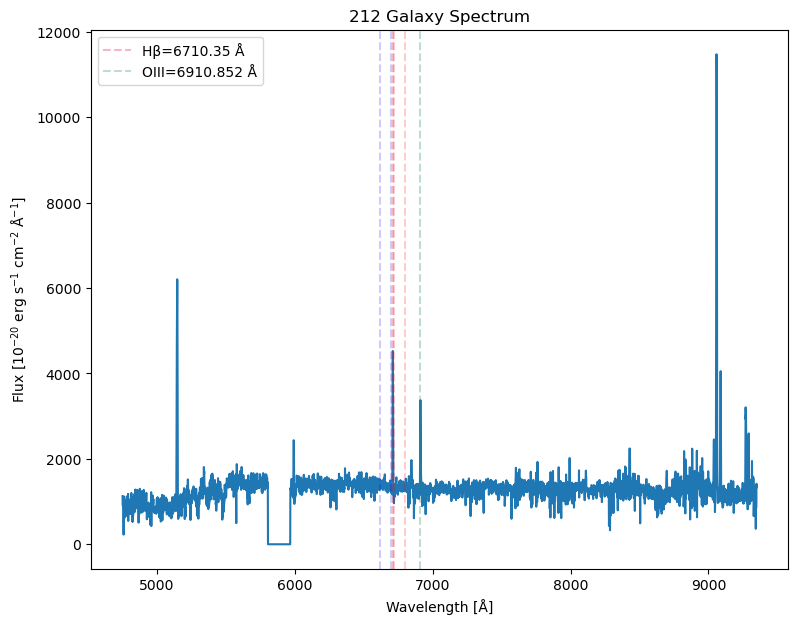

Galaxy properties:
iden  = 212
RA    = 40.0026735 deg
DEC   = -1.5644796 deg
z     = 0.37986

Observed redshifts:
z(Hb)  = 0.380352
z(OIII)= 0.380281
z(Ha)  = 0.380353
z(NII) = 0.380408

Rest wavelengths:
Hb  = 4863.066 Å
OIII= 5008.372 Å
Ha  = 6565.165 Å
NII = 6586.074 Å

Line ratios:
R1 = OIII/Hb = 0.734 ± 0.059
R2 = NII/Ha  = 0.244 ± 0.021

Log ratios:
log10(R1) = -0.135 ± 0.035
log10(R2) = -0.613 ± 0.038

O3N2 metallicity:
O3N2          = 0.479 ± 0.051
12 + log(O/H) = 8.577 ± 0.016

EW(Hβ):
Continuum at Hβ = 1340.974 ± 64.730
EW_obs(Hβ)      = 11.05 ± 0.73 Å
EW_rest(Hβ)     = 8.01 ± 0.53 Å

Star Formation Rate:
F(Hα) observed    = 6.379e-16 ± 1.362e-17 erg/s/cm²
F(Hβ) observed    = 1.482e-16 ± 6.660e-18 erg/s/cm²
F(Hα) dereddened  = 8.983e-16 ± 9.621e-17 erg/s/cm²
F(Hβ) corrected   = 1.884e-16 ± 8.874e-18 erg/s/cm²
extinction Av     = 0.480 ± 0.147
L(Hα) luminosity  = 4.410e+41 erg/s ± 4.724e+40
SFR(Hα)           = 3.484 ± 0.373 Msun/yr
log10(SFR(Hα))    = 0.542 ± 0.047 Msun/yr


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

# --------------------------------------------------
# Read catalog
# --------------------------------------------------
catalog_file = "2my_galaxies_catalog-Copy1.cat"

cat = pd.read_csv(
    catalog_file,
    sep=r"\s+",
    comment="#"
)

# --------------------------------------------------
# Select galaxy
# --------------------------------------------------
gal = cat.loc[cat["iden"] == 212].iloc[0]                                # adjust galaxy id number

iden = gal["iden"]
RA = gal["RA"]
DEC = gal["DEC"]
z_sys = gal["z"]
zconf = gal["zconf"]

# --------------------------------------------------
# Load fit
# --------------------------------------------------
df = pd.read_csv("LINES_FITS/fit_553_r5_148_263.csv")                  # replace with input file path (fit from Qfits view) in csv format

# --------------------------------------------------
# Known rest wavelengths (Angstrom) taken from http://astronomy.nmsu.edu/drewski/tableofemissionlines.html
# --------------------------------------------------
rest = {
    "Hb": 4861.333,
    "O3": 5006.843,
    "Ha": 6562.819,
    "N2": 6583.460
}

# --------------------------------------------------
# Select lines by observed wavelength
# --------------------------------------------------

Hb_exp = rest["Hb"] * (1 + z_sys)
O3_exp = rest["O3"] * (1 + z_sys)
Ha_exp = rest["Ha"] * (1 + z_sys)
N2_exp = rest["N2"] * (1 + z_sys)

Hb = df.loc[np.isclose(df["Center"], Hb_exp, atol=5.0)].iloc[0]
O3 = df.loc[np.isclose(df["Center"], O3_exp, atol=5.0)].iloc[0]
Ha = df.loc[np.isclose(df["Center"], Ha_exp, atol=5.0)].iloc[0]
N2 = df.loc[np.isclose(df["Center"], N2_exp, atol=5.0)].iloc[0]

# --------------------------------------------------
# Redshifts
# --------------------------------------------------
z_Hb = Hb["Center"] / rest["Hb"] - 1
z_O3 = O3["Center"] / rest["O3"] - 1
z_Ha = Ha["Center"] / rest["Ha"] - 1
z_N2 = N2["Center"] / rest["N2"] - 1

# --------------------------------------------------
# Rest wavelengths inferred from z
# --------------------------------------------------
Hb_rest_obs = Hb["Center"] / (1 + z_sys)
O3_rest_obs = O3["Center"] / (1 + z_sys)
Ha_rest_obs = Ha["Center"] / (1 + z_sys)
N2_rest_obs = N2["Center"] / (1 + z_sys)

# --------------------------------------------------
# Line ratios
# --------------------------------------------------
R1 = O3["Flux"] / Hb["Flux"]
R2 = N2["Flux"] / Ha["Flux"]

R1_err = R1 * np.sqrt(
    (O3["d_Flux"] / O3["Flux"])**2 +
    (Hb["d_Flux"] / Hb["Flux"])**2
)

R2_err = R2 * np.sqrt(
    (N2["d_Flux"] / N2["Flux"])**2 +
    (Ha["d_Flux"] / Ha["Flux"])**2
)

# --------------------------------------------------
# Log ratios
# --------------------------------------------------
logR1 = np.log10(R1)
logR2 = np.log10(R2)

logR1_err = R1_err / (R1 * np.log(10))
logR2_err = R2_err / (R2 * np.log(10))

# --------------------------------------------------
# O3N2 metallicity
# --------------------------------------------------
O3N2 = logR1 - logR2
O3N2_err = np.sqrt(logR1_err**2 + logR2_err**2)

OH = 8.73 - 0.32 * O3N2
OH_err = 0.32 * O3N2_err

# --------------------------------------------------
# EW(Hβ) calculation from spectrum
# --------------------------------------------------
# Load spectrum (wavelength [Å], flux density)
spec_path = "SPECTRA/id212_285_274_circ_r11"                                             # replace with spectrum file (ASCII)
spec = np.loadtxt(spec_path)

wavelength = spec[:, 0]
flux_spec  = spec[:, 1]

# Plot Spectrum
plt.figure(figsize=(9, 7))
plt.plot(wavelength, flux_spec)
#plt.xlim(6400,7000)                                                                     # adjust to see other parts of spectrum
plt.axvline(Hb["Center"], color="crimson", linestyle="--", alpha=0.3, label=f"Hβ={Hb["Center"]} Å")
plt.axvline(O3["Center"], color="seagreen", linestyle="--", alpha=0.3, label=f"OIII={O3["Center"]} Å")
#plt.axvline(Ha["Center"], color="hotpink", linestyle="--", alpha=0.3, label=f"Hα={Ha["Center"]} Å")
#plt.axvline(N2["Center"], color="gold", linestyle="--", alpha=0.3, label=f"N2={N2["Center"]} Å")
plt.axvline(Hb["Center"]-90, color="blue", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]-10, color="blue", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]+10, color="red", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]+90, color="red", linestyle="--", alpha=0.2)
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"Flux [$10^{-20}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
plt.title(f"{iden} Galaxy Spectrum")
plt.legend()
plt.show()


# --------------------------------------------------
# Continuum windows (observer frame)
# --------------------------------------------------
# Hb and O3 are roughly 98 Å apart so we assume a window of 90 Å around Hb for the calculation
# to leave space for width of line we start the window at +/- 10 Å from the center 

blue_mask = (wavelength > Hb["Center"]-90) & (wavelength < Hb["Center"]-10)                                  # adjust window around Hb line if necessary
red_mask  = (wavelength > Hb["Center"]+10) & (wavelength < Hb["Center"]+90)

# Continuum estimate
cont_blue = np.median(flux_spec[blue_mask])
cont_red  = np.median(flux_spec[red_mask])
cont_hb   = 0.5 * (cont_blue + cont_red)

# Continuum error from RMS
err_blue = np.std(flux_spec[blue_mask])
err_red  = np.std(flux_spec[red_mask])
cont_err = 0.5 * np.sqrt(err_blue**2 + err_red**2)

# --------------------------------------------------
# Equivalent width (observer frame)
# --------------------------------------------------
EW_Hb = Hb["Flux"] / cont_hb

sigma_EW_Hb = EW_Hb * np.sqrt(
    (Hb["d_Flux"] / Hb["Flux"])**2 +
    (cont_err / cont_hb)**2
)

# --------------------------------------------------
# Equivalent width (Rest-frame)
# --------------------------------------------------
EW_Hb_rest = EW_Hb / (1 + z_sys)
sigma_EW_Hb_rest = sigma_EW_Hb / (1 + z_sys)

# --------------------------------------------------
# SFR with corrected Hb
# --------------------------------------------------
DL =  2025.7   * 3.08568E+24  # [cm]                                         # go to https://www.astro.ucla.edu/~wright/CosmoCalc.html and enter: H=70, OmegaM=0.25, OmegaVac=0.75 and z of galaxy

# Observed fluxes in [erg/s/cm²]
FHa_obs = Ha["Flux"] * 1e-20
FHb_obs = Hb["Flux"] * 1e-20
d_FHa_obs = Ha["d_Flux"] * 1e-20
d_FHb_obs = Hb["d_Flux"] * 1e-20

# correct Hb for Absorption
FHb_corr = FHb_obs + 3 * FHb_obs/EW_Hb
d_FHb_corr = np.sqrt(((1 + 3/EW_Hb)*d_FHb_obs)**2 + ((-3*FHb_obs)/EW_Hb**2 * sigma_EW_Hb)**2)

# Extinction
Av = 6.547 * np.log10(FHa_obs/(2.86*FHb_corr))
d_Av = 6.547 / np.log(10) * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (d_FHb_corr / FHb_corr)**2
)

# Dereddened Ha flux
FHa_der = FHa_obs * 10**(0.31*Av)
d_FHa_der = FHa_der * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (0.31 * np.log(10) * d_Av)**2
)

# Ha luminosity
LHa = 4 * np.pi * FHa_der * DL**2
# Uncertainty on Ha luminosity
d_LHa = LHa * (d_FHa_der / FHa_der)


# SFR in Msun/yr
SFR = 7.9E-42 * LHa
#d_SFR = np.sqrt((d_FHa/FHa_obs)**2+(0.31*np.log(10)*d_Av)**2)
# SFR uncertainty
d_SFR = SFR * d_FHa_der/FHa_der


# Log10 SFR
logSFR = np.log10(SFR)
d_logSFR = 1/np.log(10) * d_FHa_der/FHa_der

# --------------------------------------------------
# Output
# --------------------------------------------------
print("Galaxy properties:")
print(f"iden  = {iden}")
print(f"RA    = {RA:.7f} deg")
print(f"DEC   = {DEC:.7f} deg")
print(f"z     = {z_sys:.5f}")

print("\nObserved redshifts:")
print(f"z(Hb)  = {z_Hb:.6f}")
print(f"z(OIII)= {z_O3:.6f}")
print(f"z(Ha)  = {z_Ha:.6f}")
print(f"z(NII) = {z_N2:.6f}")

print("\nRest wavelengths:")
print(f"Hb  = {Hb_rest_obs:.3f} Å")
print(f"OIII= {O3_rest_obs:.3f} Å")
print(f"Ha  = {Ha_rest_obs:.3f} Å")
print(f"NII = {N2_rest_obs:.3f} Å")

print("\nLine ratios:")
print(f"R1 = OIII/Hb = {R1:.3f} ± {R1_err:.3f}")
print(f"R2 = NII/Ha  = {R2:.3f} ± {R2_err:.3f}")

print("\nLog ratios:")
print(f"log10(R1) = {logR1:.3f} ± {logR1_err:.3f}")
print(f"log10(R2) = {logR2:.3f} ± {logR2_err:.3f}")

print("\nO3N2 metallicity:")
print(f"O3N2          = {O3N2:.3f} ± {O3N2_err:.3f}")
print(f"12 + log(O/H) = {OH:.3f} ± {OH_err:.3f}")

print("\nEW(Hβ):")
print(f"Continuum at Hβ = {cont_hb:.3f} ± {cont_err:.3f}")
print(f"EW_obs(Hβ)      = {EW_Hb:.2f} ± {sigma_EW_Hb:.2f} Å")
print(f"EW_rest(Hβ)     = {EW_Hb_rest:.2f} ± {sigma_EW_Hb_rest:.2f} Å")

print("\nStar Formation Rate:")
print(f"F(Hα) observed    = {FHa_obs:.3e} ± {d_FHa_obs:.3e} erg/s/cm²")
print(f"F(Hβ) observed    = {FHb_obs:.3e} ± {d_FHb_obs:.3e} erg/s/cm²")
print(f"F(Hα) dereddened  = {FHa_der:.3e} ± {d_FHa_der:.3e} erg/s/cm²")
print(f"F(Hβ) corrected   = {FHb_corr:.3e} ± {d_FHb_corr:.3e} erg/s/cm²")
print(f"extinction Av     = {Av:.3f} ± {d_Av:.3f}")
print(f"L(Hα) luminosity  = {LHa:.3e} erg/s ± {d_LHa:.3e}")
print(f"SFR(Hα)           = {SFR:.3f} ± {d_SFR:.3f} Msun/yr")
print(f"log10(SFR(Hα))    = {logSFR:.3f} ± {d_logSFR:.3f} Msun/yr")
# --------------------------------------------------
# Save results to file
# --------------------------------------------------
results = pd.DataFrame({
    "iden": [iden],
    "RA": [RA],
    "DEC": [DEC],
    "z": [z_sys],
    "R1_O3_Hb": [R1],
    "R1_err": [R1_err],
    "R2_N2_Ha": [R2],
    "R2_err": [R2_err],
    "logR1": [logR1],
    "logR1_err": [logR1_err],
    "logR2": [logR2],
    "logR2_err": [logR2_err],
    "O3N2": [O3N2],
    "O3N2_err": [O3N2_err],
    "12+log(O/H)": [OH],
    "12+log(O/H)_err": [OH_err],
    "EW_Hb_obs": [EW_Hb],
    "EW_Hb_obs_err": [sigma_EW_Hb],
    "EW_Hb_rest": [EW_Hb_rest],
    "EW_Hb_rest_err": [sigma_EW_Hb_rest],
    "SFR": [SFR],
    "d_SFR": [d_SFR],
    "log10_SFR": [logSFR],
    "d_log10_SFR": [d_logSFR]
})

results_rounded = results.copy()

cols_to_round = results.columns[4:]
results_rounded[cols_to_round] = results_rounded[cols_to_round].round(3)

#output_file = "LINES_FITS/Z_fit_1103_r5_197_285.csv"                               # replace with file path where to save results

#results_rounded.to_csv(
    #output_file,
    #index=False
    #float_format="%.3f"
#)

#print(f"\nResults written to: {output_file}")


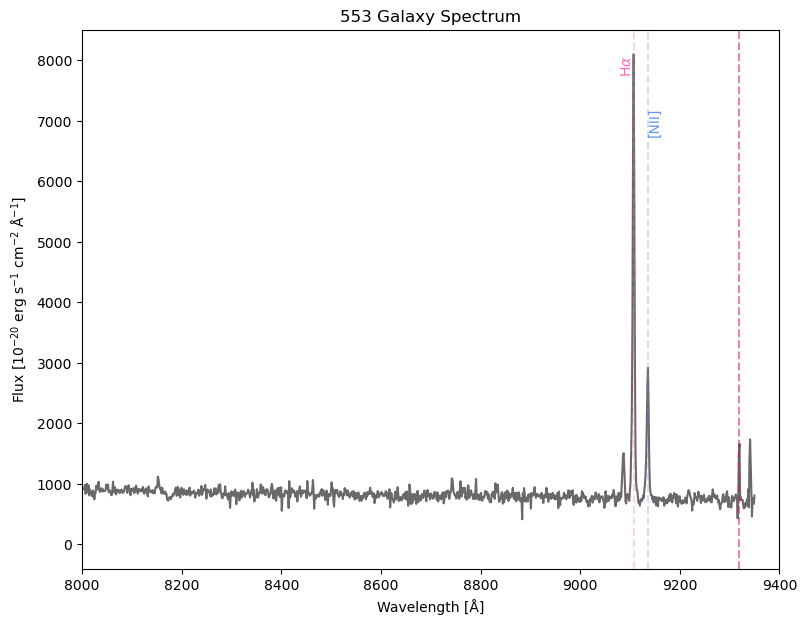

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

# --------------------------------------------------
# Read catalog
# --------------------------------------------------
catalog_file = "2my_galaxies_catalog-Copy1.cat"

cat = pd.read_csv(
    catalog_file,
    sep=r"\s+",
    comment="#"
)

# --------------------------------------------------
# Select galaxy
# --------------------------------------------------
gal = cat.loc[cat["iden"] == 553].iloc[0]                                # adjust galaxy id number

iden = gal["iden"]
RA = gal["RA"]
DEC = gal["DEC"]
z_sys = gal["z"]
zconf = gal["zconf"]

# --------------------------------------------------
# Load fit
# --------------------------------------------------
df = pd.read_csv("LINES_FITS/fit_553_r5_148_263.csv")                  # replace with input file path (fit from Qfits view) in csv format

# --------------------------------------------------
# Known rest wavelengths (Angstrom) taken from http://astronomy.nmsu.edu/drewski/tableofemissionlines.html
# --------------------------------------------------
rest = {
    "Hb": 4861.333,
    "O3": 5006.843,
    "Ha": 6562.819,
    "N2": 6583.460,
    "SIIa": 6716.440,
    "SIIb": 6730.810
}

# --------------------------------------------------
# Select lines by observed wavelength
# --------------------------------------------------

Hb_exp = rest["Hb"] * (1 + z_sys)
O3_exp = rest["O3"] * (1 + z_sys)
Ha_exp = rest["Ha"] * (1 + z_sys)
N2_exp = rest["N2"] * (1 + z_sys)
SIIa_exp = rest["SIIa"] * (1 + z_sys)
SIIb_exp = rest["SIIb"] * (1 + z_sys)

Hb = df.loc[np.isclose(df["Center"], Hb_exp, atol=5.0)].iloc[0]
O3 = df.loc[np.isclose(df["Center"], O3_exp, atol=5.0)].iloc[0]
Ha = df.loc[np.isclose(df["Center"], Ha_exp, atol=5.0)].iloc[0]
N2 = df.loc[np.isclose(df["Center"], N2_exp, atol=5.0)].iloc[0]
SIIa = df.loc[np.isclose(df["Center"], SIIa_exp, atol=5.0)].iloc[0]
SIIb = df.loc[np.isclose(df["Center"], SIIb_exp, atol=20.0)].iloc[0]

# --------------------------------------------------
# Redshifts
# --------------------------------------------------
z_Hb = Hb["Center"] / rest["Hb"] - 1
z_O3 = O3["Center"] / rest["O3"] - 1
z_Ha = Ha["Center"] / rest["Ha"] - 1
z_N2 = N2["Center"] / rest["N2"] - 1
z_SIIa = SIIa["Center"] / rest["SIIa"] - 1
z_SIIb = SIIb["Center"] / rest["SIIb"] - 1

# --------------------------------------------------
# Rest wavelengths inferred from z
# --------------------------------------------------
Hb_rest_obs = Hb["Center"] / (1 + z_sys)
O3_rest_obs = O3["Center"] / (1 + z_sys)
Ha_rest_obs = Ha["Center"] / (1 + z_sys)
N2_rest_obs = N2["Center"] / (1 + z_sys)
SIIa_rest_obs = SIIa["Center"] / (1 + z_sys)
SIIb_rest_obs = SIIb["Center"] / (1 + z_sys)



#--------------------------------------------------------------
# plotting spectrum for presentation
#------------------------------------------------------------

# Load spectrum (wavelength [Å], flux density)
spec_path = "SPECTRA/id553_148_263_circ_r5"                                             # replace with spectrum file (ASCII)
spec = np.loadtxt(spec_path)

wavelength = spec[:, 0]
flux_spec  = spec[:, 1]


fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(wavelength, flux_spec, color="dimgray")

# Vertical lines
#ax.axvline(Hb["Center"], color="crimson", linestyle="--", alpha=0.3)
#ax.axvline(O3["Center"], color="seagreen", linestyle="--", alpha=0.3)
ax.axvline(Ha["Center"], color="hotpink", linestyle="--", alpha=0.3)
ax.axvline(N2["Center"], color="cornflowerblue", linestyle="--", alpha=0.3)
ax.axvline(SIIa["Center"], color="crimson", linestyle="--", alpha=0.3)
ax.axvline(SIIb["Center"], color="crimson", linestyle="--", alpha=0.3)
# Get y-limits for label placement
ymin, ymax = ax.get_ylim()
ypos = ymax * 0.95   # place labels near the top
ypos_n2 = ymax * 0.85   # lower only N2

# Labels next to lines
#ax.text(Hb["Center"], ypos, r"H$\beta$", color="crimson",
       # rotation=90, va="top", ha="right")

#ax.text(O3["Center"], ypos, r"[OIII]", color="seagreen",
        #rotation=90, va="top", ha="right")

ax.text(Ha["Center"], ypos, r"H$\alpha$", color="hotpink",
        rotation=90, va="top", ha="right")

ax.text(N2["Center"], ypos_n2, r"[NII]", color="cornflowerblue",
        rotation=90, va="top", ha="left")

ax.set_xlabel("Wavelength [Å]")
ax.set_ylabel(r"Flux [$10^{-20}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title(f"{iden} Galaxy Spectrum")
plt.xlim(8000,9400) 
#plt.savefig("212_spectrum_plt_r7.png", dpi=300, bbox_inches="tight")
plt.show()



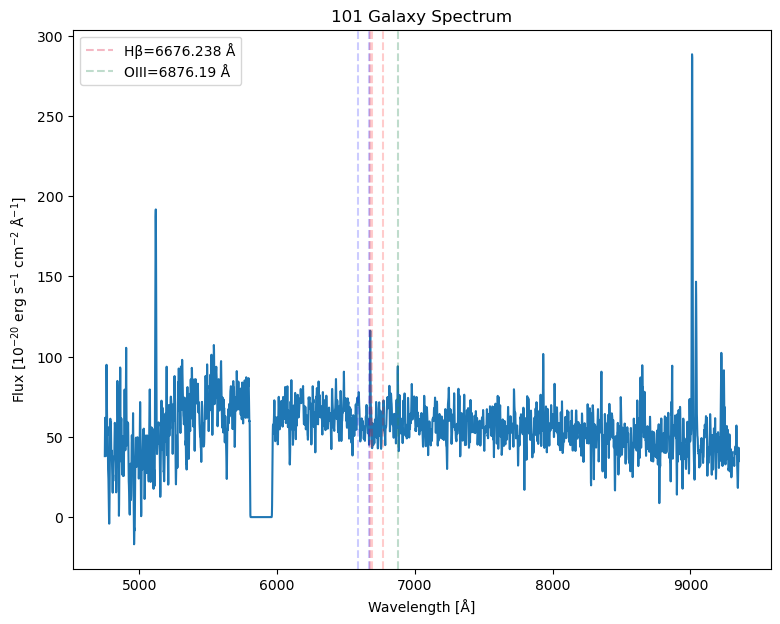

Galaxy properties:
iden  = 101
RA    = 39.9766113 deg
DEC   = -1.5595716 deg
z     = 0.37289

Observed redshifts:
z(Hb)  = 0.373335
z(OIII)= 0.373358
z(Ha)  = 0.373232
z(NII) = 0.373165

Rest wavelengths:
Hb  = 4862.908 Å
OIII= 5008.551 Å
Ha  = 6564.453 Å
NII = 6584.777 Å
SIIa  = 6718.658 Å
SIIb = 6733.070 Å

Line ratios:
R1 = OIII/Hb = 0.651 ± 0.218
R2 = NII/Ha  = 0.472 ± 0.042
R3 = SII/Ha  = 0.400 ± 0.049

Log ratios:
log10(R1) = -0.186 ± 0.146
log10(R2) = -0.326 ± 0.039
log10(R3) = -0.398 ± 0.053

O3N2 metallicity:
O3N2          = 0.139 ± 0.151
12 + log(O/H) = 8.685 ± 0.048

EW(Hβ):
Continuum at Hβ = 55.540 ± 5.601
EW_obs(Hβ)      = 3.91 ± 0.76 Å
EW_rest(Hβ)     = 2.85 ± 0.55 Å

Star Formation Rate:
F(Hα) observed    = 1.645e-17 ± 6.059e-19 erg/s/cm²
F(Hβ) observed    = 2.174e-18 ± 3.598e-19 erg/s/cm²
F(Hα) dereddened  = 3.733e-17 ± 1.440e-17 erg/s/cm²
F(Hβ) corrected   = 3.840e-18 ± 7.129e-19 erg/s/cm²
extinction Av     = 1.148 ± 0.538
L(Hα) luminosity  = 1.833e+40 erg/s ± 7.072e+3

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import csv

# --------------------------------------------------
# Read catalog
# --------------------------------------------------
catalog_file = "2my_galaxies_catalog-Copy1.cat"

cat = pd.read_csv(
    catalog_file,
    sep=r"\s+",
    comment="#"
)

# --------------------------------------------------
# Select galaxy
# --------------------------------------------------
gal = cat.loc[cat["iden"] == 101].iloc[0]                                # adjust galaxy id number

iden = gal["iden"]
RA = gal["RA"]
DEC = gal["DEC"]
z_sys = gal["z"]
zconf = gal["zconf"]

# --------------------------------------------------
# Load fit
# --------------------------------------------------
df = pd.read_csv("LINES_FITS/fit_101_r2_211_42_smooth.csv")                  # replace with input file path (fit from Qfits view) in csv format

# --------------------------------------------------
# Known rest wavelengths (Angstrom) taken from http://astronomy.nmsu.edu/drewski/tableofemissionlines.html
# --------------------------------------------------
rest = {
    "Hb": 4861.333,
    "O3": 5006.843,
    "Ha": 6562.819,
    "N2": 6583.460,
    "SIIa": 6716.440,
    "SIIb": 6730.810
}

# --------------------------------------------------
# Select lines by observed wavelength
# --------------------------------------------------

Hb_exp = rest["Hb"] * (1 + z_sys)
O3_exp = rest["O3"] * (1 + z_sys)
Ha_exp = rest["Ha"] * (1 + z_sys)
N2_exp = rest["N2"] * (1 + z_sys)
SIIa_exp = rest["SIIa"] * (1 + z_sys)
SIIb_exp = rest["SIIb"] * (1 + z_sys)

Hb = df.loc[np.isclose(df["Center"], Hb_exp, atol=5.0)].iloc[0]
O3 = df.loc[np.isclose(df["Center"], O3_exp, atol=5.0)].iloc[0]
Ha = df.loc[np.isclose(df["Center"], Ha_exp, atol=5.0)].iloc[0]
N2 = df.loc[np.isclose(df["Center"], N2_exp, atol=5.0)].iloc[0]
SIIa = df.loc[np.isclose(df["Center"], SIIa_exp, atol=5.0)].iloc[0]
SIIb = df.loc[np.isclose(df["Center"], SIIb_exp, atol=5.0)].iloc[0]


# --------------------------------------------------
# Redshifts
# --------------------------------------------------
z_Hb = Hb["Center"] / rest["Hb"] - 1
z_O3 = O3["Center"] / rest["O3"] - 1
z_Ha = Ha["Center"] / rest["Ha"] - 1
z_N2 = N2["Center"] / rest["N2"] - 1
z_SIIa = SIIa["Center"] / rest["SIIa"] - 1
z_SIIb = SIIb["Center"] / rest["SIIb"] - 1

# --------------------------------------------------
# Rest wavelengths inferred from z
# --------------------------------------------------
Hb_rest_obs = Hb["Center"] / (1 + z_sys)
O3_rest_obs = O3["Center"] / (1 + z_sys)
Ha_rest_obs = Ha["Center"] / (1 + z_sys)
N2_rest_obs = N2["Center"] / (1 + z_sys)
SIIa_rest_obs = SIIa["Center"] / (1 + z_sys)
SIIb_rest_obs = SIIb["Center"] / (1 + z_sys)

#------------------------------------------------------------
# LINE RATIOS
#------------------------------------------------------------
R1 = O3["Flux"] / Hb["Flux"]
R2 = N2["Flux"] / Ha["Flux"]

SII_sum = SIIa["Flux"] + SIIb["Flux"]
R3 = SII_sum/Ha["Flux"]

R1_err = R1 * np.sqrt(
    (O3["d_Flux"] / O3["Flux"])**2 +
    (Hb["d_Flux"] / Hb["Flux"])**2
)

R2_err = R2 * np.sqrt(
    (N2["d_Flux"] / N2["Flux"])**2 +
    (Ha["d_Flux"] / Ha["Flux"])**2
)

SII_sum_err = np.sqrt(
    SIIa["d_Flux"]**2 +
    SIIb["d_Flux"]**2
)

R3_err = R3 * np.sqrt(
    (SII_sum_err / SII_sum)**2 +
    (Ha["d_Flux"] / Ha["Flux"])**2
)
# --------------------------------------------------
# Log ratios
# --------------------------------------------------
logR1 = np.log10(R1)
logR2 = np.log10(R2)
logR3 = np.log10(R3)

logR1_err = R1_err / (R1 * np.log(10))
logR2_err = R2_err / (R2 * np.log(10))
logR3_err = R3_err / (R3 * np.log(10))
# --------------------------------------------------
# O3N2 metallicity
# --------------------------------------------------
O3N2 = logR1 - logR2
O3N2_err = np.sqrt(logR1_err**2 + logR2_err**2)

OH = 8.73 - 0.32 * O3N2
OH_err = 0.32 * O3N2_err

# --------------------------------------------------
# EW(Hβ) calculation from spectrum
# --------------------------------------------------
# Load spectrum (wavelength [Å], flux density)
spec_path = "SPECTRA/id101_211_42_circ_r2_smooth"                                             # replace with spectrum file (ASCII)
spec = np.loadtxt(spec_path)

wavelength = spec[:, 0]
flux_spec  = spec[:, 1]

# Plot Spectrum
plt.figure(figsize=(9, 7))
plt.plot(wavelength, flux_spec)
#plt.xlim(6400,7000)                                                                     # adjust to see other parts of spectrum
plt.axvline(Hb["Center"], color="crimson", linestyle="--", alpha=0.3, label=f"Hβ={Hb["Center"]} Å")
plt.axvline(O3["Center"], color="seagreen", linestyle="--", alpha=0.3, label=f"OIII={O3["Center"]} Å")
#plt.axvline(Ha["Center"], color="hotpink", linestyle="--", alpha=0.3, label=f"Hα={Ha["Center"]} Å")
#plt.axvline(N2["Center"], color="gold", linestyle="--", alpha=0.3, label=f"N2={N2["Center"]} Å")
plt.axvline(Hb["Center"]-90, color="blue", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]-10, color="blue", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]+10, color="red", linestyle="--", alpha=0.2)
plt.axvline(Hb["Center"]+90, color="red", linestyle="--", alpha=0.2)
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"Flux [$10^{-20}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
plt.title(f"{iden} Galaxy Spectrum")
plt.legend()
plt.show()


# --------------------------------------------------
# Continuum windows (observer frame)
# --------------------------------------------------
# Hb and O3 are roughly 98 Å apart so we assume a window of 90 Å around Hb for the calculation
# to leave space for width of line we start the window at +/- 10 Å from the center 

blue_mask = (wavelength > Hb["Center"]-90) & (wavelength < Hb["Center"]-10)                                  # adjust window around Hb line if necessary
red_mask  = (wavelength > Hb["Center"]+10) & (wavelength < Hb["Center"]+90)

# Continuum estimate
cont_blue = np.median(flux_spec[blue_mask])
cont_red  = np.median(flux_spec[red_mask])
cont_hb   = 0.5 * (cont_blue + cont_red)

# Continuum error from RMS
err_blue = np.std(flux_spec[blue_mask])
err_red  = np.std(flux_spec[red_mask])
cont_err = 0.5 * np.sqrt(err_blue**2 + err_red**2)

# --------------------------------------------------
# Equivalent width (observer frame)
# --------------------------------------------------
EW_Hb = Hb["Flux"] / cont_hb

sigma_EW_Hb = EW_Hb * np.sqrt(
    (Hb["d_Flux"] / Hb["Flux"])**2 +
    (cont_err / cont_hb)**2
)

# --------------------------------------------------
# Equivalent width (Rest-frame)
# --------------------------------------------------
EW_Hb_rest = EW_Hb / (1 + z_sys)
sigma_EW_Hb_rest = sigma_EW_Hb / (1 + z_sys)

# --------------------------------------------------
# SFR with corrected Hb
# --------------------------------------------------
DL =  2025.7   * 3.08568E+24  # [cm]                                         # go to https://www.astro.ucla.edu/~wright/CosmoCalc.html and enter: H=70, OmegaM=0.25, OmegaVac=0.75 and z of galaxy

# Observed fluxes in [erg/s/cm²]
FHa_obs = Ha["Flux"] * 1e-20
FHb_obs = Hb["Flux"] * 1e-20
d_FHa_obs = Ha["d_Flux"] * 1e-20
d_FHb_obs = Hb["d_Flux"] * 1e-20

# correct Hb for Absorption
FHb_corr = FHb_obs + 3 * FHb_obs/EW_Hb
d_FHb_corr = np.sqrt(((1 + 3/EW_Hb)*d_FHb_obs)**2 + ((-3*FHb_obs)/EW_Hb**2 * sigma_EW_Hb)**2)

# Extinction
Av = 6.547 * np.log10(FHa_obs/(2.86*FHb_corr))
d_Av = 6.547 / np.log(10) * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (d_FHb_corr / FHb_corr)**2
)

# Dereddened Ha flux
FHa_der = FHa_obs * 10**(0.31*Av)
d_FHa_der = FHa_der * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (0.31 * np.log(10) * d_Av)**2
)

# Ha luminosity
LHa = 4 * np.pi * FHa_der * DL**2
# Uncertainty on Ha luminosity
d_LHa = LHa * (d_FHa_der / FHa_der)


# SFR in Msun/yr
SFR = 7.9E-42 * LHa
#d_SFR = np.sqrt((d_FHa/FHa_obs)**2+(0.31*np.log(10)*d_Av)**2)
# SFR uncertainty
d_SFR = SFR * d_FHa_der/FHa_der


# Log10 SFR
logSFR = np.log10(SFR)

# Linear bounds
SFR_low = SFR - d_SFR
SFR_up  = SFR + d_SFR

# Avoid non-physical negative values
if SFR_low <= 0:
    SFR_low = np.nan

# Log bounds
logSFR_low = np.log10(SFR_low)
logSFR_up  = np.log10(SFR_up)

# Asymmetric uncertainties in dex
d_logSFR_low = logSFR - logSFR_low
d_logSFR_up  = logSFR_up - logSFR
# --------------------------------------------------
# Output
# --------------------------------------------------
print("Galaxy properties:")
print(f"iden  = {iden}")
print(f"RA    = {RA:.7f} deg")
print(f"DEC   = {DEC:.7f} deg")
print(f"z     = {z_sys:.5f}")

print("\nObserved redshifts:")
print(f"z(Hb)  = {z_Hb:.6f}")
print(f"z(OIII)= {z_O3:.6f}")
print(f"z(Ha)  = {z_Ha:.6f}")
print(f"z(NII) = {z_N2:.6f}")

print("\nRest wavelengths:")
print(f"Hb  = {Hb_rest_obs:.3f} Å")
print(f"OIII= {O3_rest_obs:.3f} Å")
print(f"Ha  = {Ha_rest_obs:.3f} Å")
print(f"NII = {N2_rest_obs:.3f} Å")
print(f"SIIa  = {SIIa_rest_obs:.3f} Å")
print(f"SIIb = {SIIb_rest_obs:.3f} Å")

print("\nLine ratios:")
print(f"R1 = OIII/Hb = {R1:.3f} ± {R1_err:.3f}")
print(f"R2 = NII/Ha  = {R2:.3f} ± {R2_err:.3f}")
print(f"R3 = SII/Ha  = {R3:.3f} ± {R3_err:.3f}")

print("\nLog ratios:")
print(f"log10(R1) = {logR1:.3f} ± {logR1_err:.3f}")
print(f"log10(R2) = {logR2:.3f} ± {logR2_err:.3f}")
print(f"log10(R3) = {logR3:.3f} ± {logR3_err:.3f}")


print("\nO3N2 metallicity:")
print(f"O3N2          = {O3N2:.3f} ± {O3N2_err:.3f}")
print(f"12 + log(O/H) = {OH:.3f} ± {OH_err:.3f}")

print("\nEW(Hβ):")
print(f"Continuum at Hβ = {cont_hb:.3f} ± {cont_err:.3f}")
print(f"EW_obs(Hβ)      = {EW_Hb:.2f} ± {sigma_EW_Hb:.2f} Å")
print(f"EW_rest(Hβ)     = {EW_Hb_rest:.2f} ± {sigma_EW_Hb_rest:.2f} Å")

print("\nStar Formation Rate:")
print(f"F(Hα) observed    = {FHa_obs:.3e} ± {d_FHa_obs:.3e} erg/s/cm²")
print(f"F(Hβ) observed    = {FHb_obs:.3e} ± {d_FHb_obs:.3e} erg/s/cm²")
print(f"F(Hα) dereddened  = {FHa_der:.3e} ± {d_FHa_der:.3e} erg/s/cm²")
print(f"F(Hβ) corrected   = {FHb_corr:.3e} ± {d_FHb_corr:.3e} erg/s/cm²")
print(f"extinction Av     = {Av:.3f} ± {d_Av:.3f}")
print(f"L(Hα) luminosity  = {LHa:.3e} erg/s ± {d_LHa:.3e}")
print(f"SFR(Hα)           = {SFR:.3f} ± {d_SFR:.3f} Msun/yr")
print(f"log10(SFR(Hα))    = {logSFR:.3f} (+{d_logSFR_up:.3f} / -{d_logSFR_low:.3f}) dex")
# --------------------------------------------------
# Save results to file
# --------------------------------------------------
results = pd.DataFrame({
    "iden": [iden],
    "RA": [RA],
    "DEC": [DEC],
    "z": [z_sys],
    "R1_O3_Hb": [R1],
    "R1_err": [R1_err],
    "R2_N2_Ha": [R2],
    "R2_err": [R2_err],
    "R3_SII_Ha": [R3],
    "R3_err": [R3_err],
    "logR1": [logR1],
    "logR1_err": [logR1_err],
    "logR2": [logR2],
    "logR2_err": [logR2_err],
    "logR3": [logR3],
    "logR3_err": [logR3_err],
    "O3N2": [O3N2],
    "O3N2_err": [O3N2_err],
    "12+log(O/H)": [OH],
    "12+log(O/H)_err": [OH_err],
    "EW_Hb_obs": [EW_Hb],
    "EW_Hb_obs_err": [sigma_EW_Hb],
    "EW_Hb_rest": [EW_Hb_rest],
    "EW_Hb_rest_err": [sigma_EW_Hb_rest],
    "SFR": [SFR],
    "d_SFR": [d_SFR],
    "log10_SFR": [logSFR],
    "d_log10_SFR_up": [d_logSFR_up],
    "d_log10_SFR_low": [d_logSFR_low]
})

results_rounded = results.copy()

cols_to_round = results.columns[4:]
results_rounded[cols_to_round] = results_rounded[cols_to_round].round(3)

output_file = "LINES_FITS/Z_fit_101_r2_211_42_smooth.csv"                               # replace with file path where to save results

results_rounded.to_csv(
    output_file,
    index=False,
    float_format="%.3f"
)

print(f"\nResults written to: {output_file}")




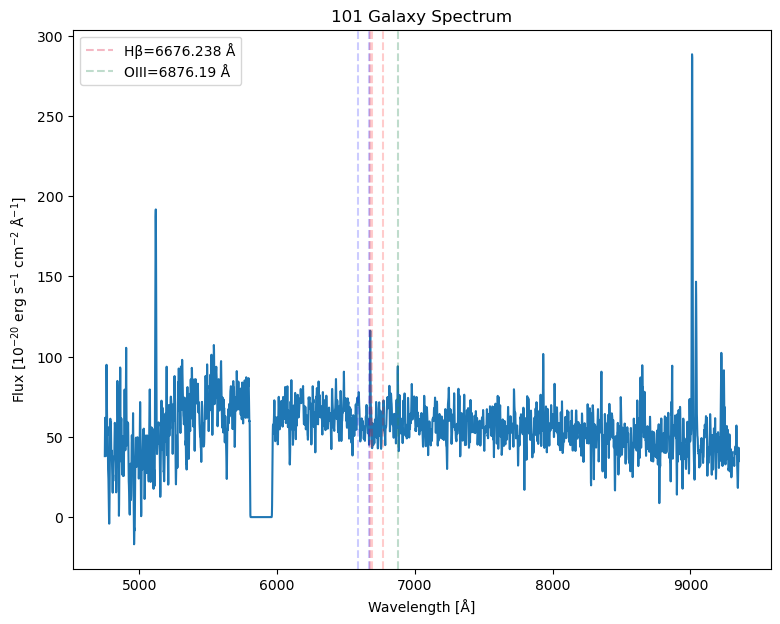

Galaxy properties:
iden  = 101
RA    = 39.9766113 deg
DEC   = -1.5595716 deg
z     = 0.37289

Observed redshifts:
z(Hb)  = 0.373335
z(OIII)= 0.373358
z(Ha)  = 0.373232
z(NII) = 0.373165

Rest wavelengths:
Hb  = 4862.908 Å
OIII= 5008.551 Å
Ha  = 6564.453 Å
NII = 6584.777 Å
SIIa  = 6718.658 Å
SIIb = 6733.070 Å

Line ratios:
R1 = OIII/Hb = 0.651 ± 0.218
R2 = NII/Ha  = 0.472 ± 0.042
R3 = SII/Ha  = 0.400 ± 0.049

Log ratios:
log10(R1) = -0.186 ± 0.146
log10(R2) = -0.326 ± 0.039
log10(R3) = -0.398 ± 0.053

O3N2 metallicity:
O3N2          = 0.139 ± 0.151
12 + log(O/H) = 8.685 ± 0.048

EW(Hβ):
Continuum at Hβ = 55.540 ± 5.601
EW_obs(Hβ)      = 3.91 ± 0.76 Å
EW_rest(Hβ)     = 2.85 ± 0.55 Å

Star Formation Rate:
F(Hα) observed    = 1.645e-17 ± 6.059e-19 erg/s/cm²
F(Hβ) observed    = 2.174e-18 ± 3.598e-19 erg/s/cm²
F(Hα) dereddened  = 3.733e-17 ± 1.440e-17 erg/s/cm²
F(Hβ) corrected   = 3.840e-18 ± 7.129e-19 erg/s/cm²
extinction Av     = 1.148 ± 0.538
L(Hα) luminosity  = 1.833e+40 erg/s ± 7.072e+3

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Read catalog
# --------------------------------------------------
catalog_file = "2my_galaxies_catalog-Copy1.cat"

cat = pd.read_csv(
    catalog_file,
    sep=r"\s+",
    comment="#"
)

# --------------------------------------------------
# Select galaxy
# --------------------------------------------------
gal = cat.loc[cat["iden"] == 101].iloc[0]                                # adjust galaxy id number

iden = gal["iden"]
RA = gal["RA"]
DEC = gal["DEC"]
z_sys = gal["z"]
zconf = gal["zconf"]

# --------------------------------------------------
# Load fit
# --------------------------------------------------
df = pd.read_csv("LINES_FITS/fit_101_r2_211_42_smooth.csv")                  # replace with input file path (fit from Qfits view) in csv format

# --------------------------------------------------
# Known rest wavelengths (Angstrom) taken from http://astronomy.nmsu.edu/drewski/tableofemissionlines.html
# --------------------------------------------------
rest = {
    "Hb": 4861.333,
    "O3": 5006.843,
    "Ha": 6562.819,
    "N2": 6583.460,
    "SIIa": 6716.440,
    "SIIb": 6730.810
}

# --------------------------------------------------
# Select lines by observed wavelength
# --------------------------------------------------

Hb_exp = rest["Hb"] * (1 + z_sys)
O3_exp = rest["O3"] * (1 + z_sys)
Ha_exp = rest["Ha"] * (1 + z_sys)
N2_exp = rest["N2"] * (1 + z_sys)
SIIa_exp = rest["SIIa"] * (1 + z_sys)
SIIb_exp = rest["SIIb"] * (1 + z_sys)

def get_line(df, expected_center):
    idx = np.abs(df["Center"].values - expected_center).argmin()
    return df.iloc[idx]

Hb  = get_line(df, Hb_exp)
O3  = get_line(df, O3_exp)
Ha  = get_line(df, Ha_exp)
N2  = get_line(df, N2_exp)
SIIa = get_line(df, SIIa_exp)
SIIb = get_line(df, SIIb_exp)

# --------------------------------------------------
# Redshifts
# --------------------------------------------------
z_Hb = Hb["Center"] / rest["Hb"] - 1
z_O3 = O3["Center"] / rest["O3"] - 1
z_Ha = Ha["Center"] / rest["Ha"] - 1
z_N2 = N2["Center"] / rest["N2"] - 1
z_SIIa = SIIa["Center"] / rest["SIIa"] - 1
z_SIIb = SIIb["Center"] / rest["SIIb"] - 1

# --------------------------------------------------
# Rest wavelengths inferred from z
# --------------------------------------------------
Hb_rest_obs = Hb["Center"] / (1 + z_sys)
O3_rest_obs = O3["Center"] / (1 + z_sys)
Ha_rest_obs = Ha["Center"] / (1 + z_sys)
N2_rest_obs = N2["Center"] / (1 + z_sys)
SIIa_rest_obs = SIIa["Center"] / (1 + z_sys)
SIIb_rest_obs = SIIb["Center"] / (1 + z_sys)

#------------------------------------------------------------
# LINE RATIOS
#------------------------------------------------------------
R1 = O3["Flux"] / Hb["Flux"]
R2 = N2["Flux"] / Ha["Flux"]

SII_sum = SIIa["Flux"] + SIIb["Flux"]
R3 = SII_sum/Ha["Flux"]

R1_err = R1 * np.sqrt(
    (O3["d_Flux"] / O3["Flux"])**2 +
    (Hb["d_Flux"] / Hb["Flux"])**2
)

R2_err = R2 * np.sqrt(
    (N2["d_Flux"] / N2["Flux"])**2 +
    (Ha["d_Flux"] / Ha["Flux"])**2
)

SII_sum_err = np.sqrt(
    SIIa["d_Flux"]**2 +
    SIIb["d_Flux"]**2
)

R3_err = R3 * np.sqrt(
    (SII_sum_err / SII_sum)**2 +
    (Ha["d_Flux"] / Ha["Flux"])**2
)
# --------------------------------------------------
# Log ratios
# --------------------------------------------------
logR1 = np.log10(R1)
logR2 = np.log10(R2)
logR3 = np.log10(R3)

logR1_err = R1_err / (R1 * np.log(10))
logR2_err = R2_err / (R2 * np.log(10))
logR3_err = R3_err / (R3 * np.log(10))
# --------------------------------------------------
# O3N2 metallicity
# --------------------------------------------------
O3N2 = logR1 - logR2
O3N2_err = np.sqrt(logR1_err**2 + logR2_err**2)

OH = 8.73 - 0.32 * O3N2
OH_err = 0.32 * O3N2_err

# --------------------------------------------------
# EW(Hβ) calculation from spectrum
# --------------------------------------------------
# Load spectrum (wavelength [Å], flux density)
spec_path = "SPECTRA/id101_211_42_circ_r2_smooth"                                             # replace with spectrum file (ASCII)
spec = np.loadtxt(spec_path)

wavelength = spec[:, 0]
flux_spec  = spec[:, 1]


# --------------------------------------------------
# Continuum windows (observer frame)
# --------------------------------------------------
# Hb and O3 are roughly 98 Å apart so we assume a window of 90 Å around Hb for the calculation
# to leave space for width of line we start the window at +/- 10 Å from the center 

blue_mask = (wavelength > Hb["Center"]-90) & (wavelength < Hb["Center"]-10)                                  # adjust window around Hb line if necessary
red_mask  = (wavelength > Hb["Center"]+10) & (wavelength < Hb["Center"]+90)

# Continuum estimate
cont_blue = np.median(flux_spec[blue_mask])
cont_red  = np.median(flux_spec[red_mask])
cont_hb   = 0.5 * (cont_blue + cont_red)

# Continuum error from RMS
err_blue = np.std(flux_spec[blue_mask])
err_red  = np.std(flux_spec[red_mask])
cont_err = 0.5 * np.sqrt(err_blue**2 + err_red**2)

# --------------------------------------------------
# Equivalent width (observer frame)
# --------------------------------------------------
EW_Hb = Hb["Flux"] / cont_hb

sigma_EW_Hb = EW_Hb * np.sqrt(
    (Hb["d_Flux"] / Hb["Flux"])**2 +
    (cont_err / cont_hb)**2
)

# --------------------------------------------------
# Equivalent width (Rest-frame)
# --------------------------------------------------
EW_Hb_rest = EW_Hb / (1 + z_sys)
sigma_EW_Hb_rest = sigma_EW_Hb / (1 + z_sys)

# --------------------------------------------------
# SFR with corrected Hb
# --------------------------------------------------
DL =  2025.7   * 3.08568E+24  # [cm]                                         # go to https://www.astro.ucla.edu/~wright/CosmoCalc.html and enter: H=70, OmegaM=0.25, OmegaVac=0.75 and z of galaxy

# Observed fluxes in [erg/s/cm²]
FHa_obs = Ha["Flux"] * 1e-20
FHb_obs = Hb["Flux"] * 1e-20
d_FHa_obs = Ha["d_Flux"] * 1e-20
d_FHb_obs = Hb["d_Flux"] * 1e-20

# correct Hb for Absorption
FHb_corr = FHb_obs + 3 * FHb_obs/EW_Hb
d_FHb_corr = np.sqrt(((1 + 3/EW_Hb)*d_FHb_obs)**2 + ((-3*FHb_obs)/EW_Hb**2 * sigma_EW_Hb)**2)

# Extinction
Av = 6.547 * np.log10(FHa_obs/(2.86*FHb_corr))
d_Av = 6.547 / np.log(10) * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (d_FHb_corr / FHb_corr)**2
)

# Dereddened Ha flux
FHa_der = FHa_obs * 10**(0.31*Av)
d_FHa_der = FHa_der * np.sqrt(
    (d_FHa_obs / FHa_obs)**2 + (0.31 * np.log(10) * d_Av)**2
)

# Ha luminosity
LHa = 4 * np.pi * FHa_der * DL**2
# Uncertainty on Ha luminosity
d_LHa = LHa * (d_FHa_der / FHa_der)


# SFR in Msun/yr
SFR = 7.9E-42 * LHa
#d_SFR = np.sqrt((d_FHa/FHa_obs)**2+(0.31*np.log(10)*d_Av)**2)
# SFR uncertainty
d_SFR = SFR * d_FHa_der/FHa_der


# Log10 SFR
logSFR = np.log10(SFR)

# Linear bounds
SFR_low = SFR - d_SFR
SFR_up  = SFR + d_SFR

# Avoid non-physical negative values
if SFR_low <= 0:
    SFR_low = np.nan

# Log bounds
logSFR_low = np.log10(SFR_low)
logSFR_up  = np.log10(SFR_up)

# Asymmetric uncertainties in dex
d_logSFR_low = logSFR - logSFR_low
d_logSFR_up  = logSFR_up - logSFR
# --------------------------------------------------
# Output
# --------------------------------------------------
print("Galaxy properties:")
print(f"iden  = {iden}")
print(f"RA    = {RA:.7f} deg")
print(f"DEC   = {DEC:.7f} deg")
print(f"z     = {z_sys:.5f}")

print("\nObserved redshifts:")
print(f"z(Hb)  = {z_Hb:.6f}")
print(f"z(OIII)= {z_O3:.6f}")
print(f"z(Ha)  = {z_Ha:.6f}")
print(f"z(NII) = {z_N2:.6f}")

print("\nRest wavelengths:")
print(f"Hb  = {Hb_rest_obs:.3f} Å")
print(f"OIII= {O3_rest_obs:.3f} Å")
print(f"Ha  = {Ha_rest_obs:.3f} Å")
print(f"NII = {N2_rest_obs:.3f} Å")
print(f"SIIa  = {SIIa_rest_obs:.3f} Å")
print(f"SIIb = {SIIb_rest_obs:.3f} Å")

print("\nLine ratios:")
print(f"R1 = OIII/Hb = {R1:.3f} ± {R1_err:.3f}")
print(f"R2 = NII/Ha  = {R2:.3f} ± {R2_err:.3f}")
print(f"R3 = SII/Ha  = {R3:.3f} ± {R3_err:.3f}")

print("\nLog ratios:")
print(f"log10(R1) = {logR1:.3f} ± {logR1_err:.3f}")
print(f"log10(R2) = {logR2:.3f} ± {logR2_err:.3f}")
print(f"log10(R3) = {logR3:.3f} ± {logR3_err:.3f}")


print("\nO3N2 metallicity:")
print(f"O3N2          = {O3N2:.3f} ± {O3N2_err:.3f}")
print(f"12 + log(O/H) = {OH:.3f} ± {OH_err:.3f}")

print("\nEW(Hβ):")
print(f"Continuum at Hβ = {cont_hb:.3f} ± {cont_err:.3f}")
print(f"EW_obs(Hβ)      = {EW_Hb:.2f} ± {sigma_EW_Hb:.2f} Å")
print(f"EW_rest(Hβ)     = {EW_Hb_rest:.2f} ± {sigma_EW_Hb_rest:.2f} Å")

print("\nStar Formation Rate:")
print(f"F(Hα) observed    = {FHa_obs:.3e} ± {d_FHa_obs:.3e} erg/s/cm²")
print(f"F(Hβ) observed    = {FHb_obs:.3e} ± {d_FHb_obs:.3e} erg/s/cm²")
print(f"F(Hα) dereddened  = {FHa_der:.3e} ± {d_FHa_der:.3e} erg/s/cm²")
print(f"F(Hβ) corrected   = {FHb_corr:.3e} ± {d_FHb_corr:.3e} erg/s/cm²")
print(f"extinction Av     = {Av:.3f} ± {d_Av:.3f}")
print(f"L(Hα) luminosity  = {LHa:.3e} erg/s ± {d_LHa:.3e}")
print(f"SFR(Hα)           = {SFR:.3f} ± {d_SFR:.3f} Msun/yr")
print(f"log10(SFR(Hα))    = {logSFR:.3f} (+{d_logSFR_up:.3f} / -{d_logSFR_low:.3f}) dex")
# --------------------------------------------------
# Save results to file
# --------------------------------------------------
results = pd.DataFrame({
    "iden": [iden],
    "RA": [RA],
    "DEC": [DEC],
    "z": [z_sys],
    "R1_O3_Hb": [R1],
    "R1_err": [R1_err],
    "R2_N2_Ha": [R2],
    "R2_err": [R2_err],
    "R3_SII_Ha": [R3],
    "R3_err": [R3_err],
    "logR1": [logR1],
    "logR1_err": [logR1_err],
    "logR2": [logR2],
    "logR2_err": [logR2_err],
    "logR3": [logR3],
    "logR3_err": [logR3_err],
    "O3N2": [O3N2],
    "O3N2_err": [O3N2_err],
    "12+log(O/H)": [OH],
    "12+log(O/H)_err": [OH_err],
    "EW_Hb_obs": [EW_Hb],
    "EW_Hb_obs_err": [sigma_EW_Hb],
    "EW_Hb_rest": [EW_Hb_rest],
    "EW_Hb_rest_err": [sigma_EW_Hb_rest],
    "SFR": [SFR],
    "d_SFR": [d_SFR],
    "log10_SFR": [logSFR],
    "d_log10_SFR_up": [d_logSFR_up],
    "d_log10_SFR_low": [d_logSFR_low]
})

results_rounded = results.copy()

cols_to_round = results.columns[4:]
results_rounded[cols_to_round] = results_rounded[cols_to_round].round(3)

output_file = "LINES_FITS/Z_fit_101_r2_211_42_smooth.csv"                               # replace with file path where to save results

results_rounded.to_csv(
    output_file,
    index=False,
    float_format="%.3f"
)

print(f"\nResults written to: {output_file}")


